In [58]:
import numpy as np
import pandas as pd
import seaborn as sns

In [59]:
def plot_facetgrid(dataset):
    df = pd.read_csv(f'../../data/processed/{dataset}_correlations.csv')
    df['abs_corr'] = df.r.apply(np.abs)
    df['family'] = df.model.apply(lambda x: x.split('_')[0])
    df.nlp_metric = df.nlp_metric.apply(lambda x: x if x != 'htd' else 'htd_nlp')
    df.family.unique()
    df.model.unique()
    g = sns.FacetGrid(df, col='validity_metric', row='nlp_metric').set_titles('{col_name} | {row_name}')
    g.map_dataframe(sns.barplot, x='model', y='abs_corr', hue='family', palette='husl', order=['llm_gemini', 'llm_mistral', 'sentence_t5', 'sentence_roberta', 
           'task_nli_deberta_entailment', 'task_nli_deberta_contradiction',
           'task_nli_deberta_neutral', 'task_sts_cross_encoder',
           'word_ft_wmd', 'word_w2v_wmd', 'word_glove_wmd', 'word_ft_cosine', 
           'word_w2v_cosine', 'word_glove_cosine',], hue_order=['llm', 'task', 'sentence', 'word'])
    
    
    for ax in g.axes.flat:
        ax.tick_params(axis='x', which='both', rotation=90)
    g.figure.tight_layout()
    g.figure.savefig(f'../../reports/figures/{dataset}_correlations.png', bbox_inches='tight', dpi=300)
    g.figure.show()

C:\Users\hide\AppData\Local\Temp\ipykernel_7328\2817206245.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  g.figure.show()


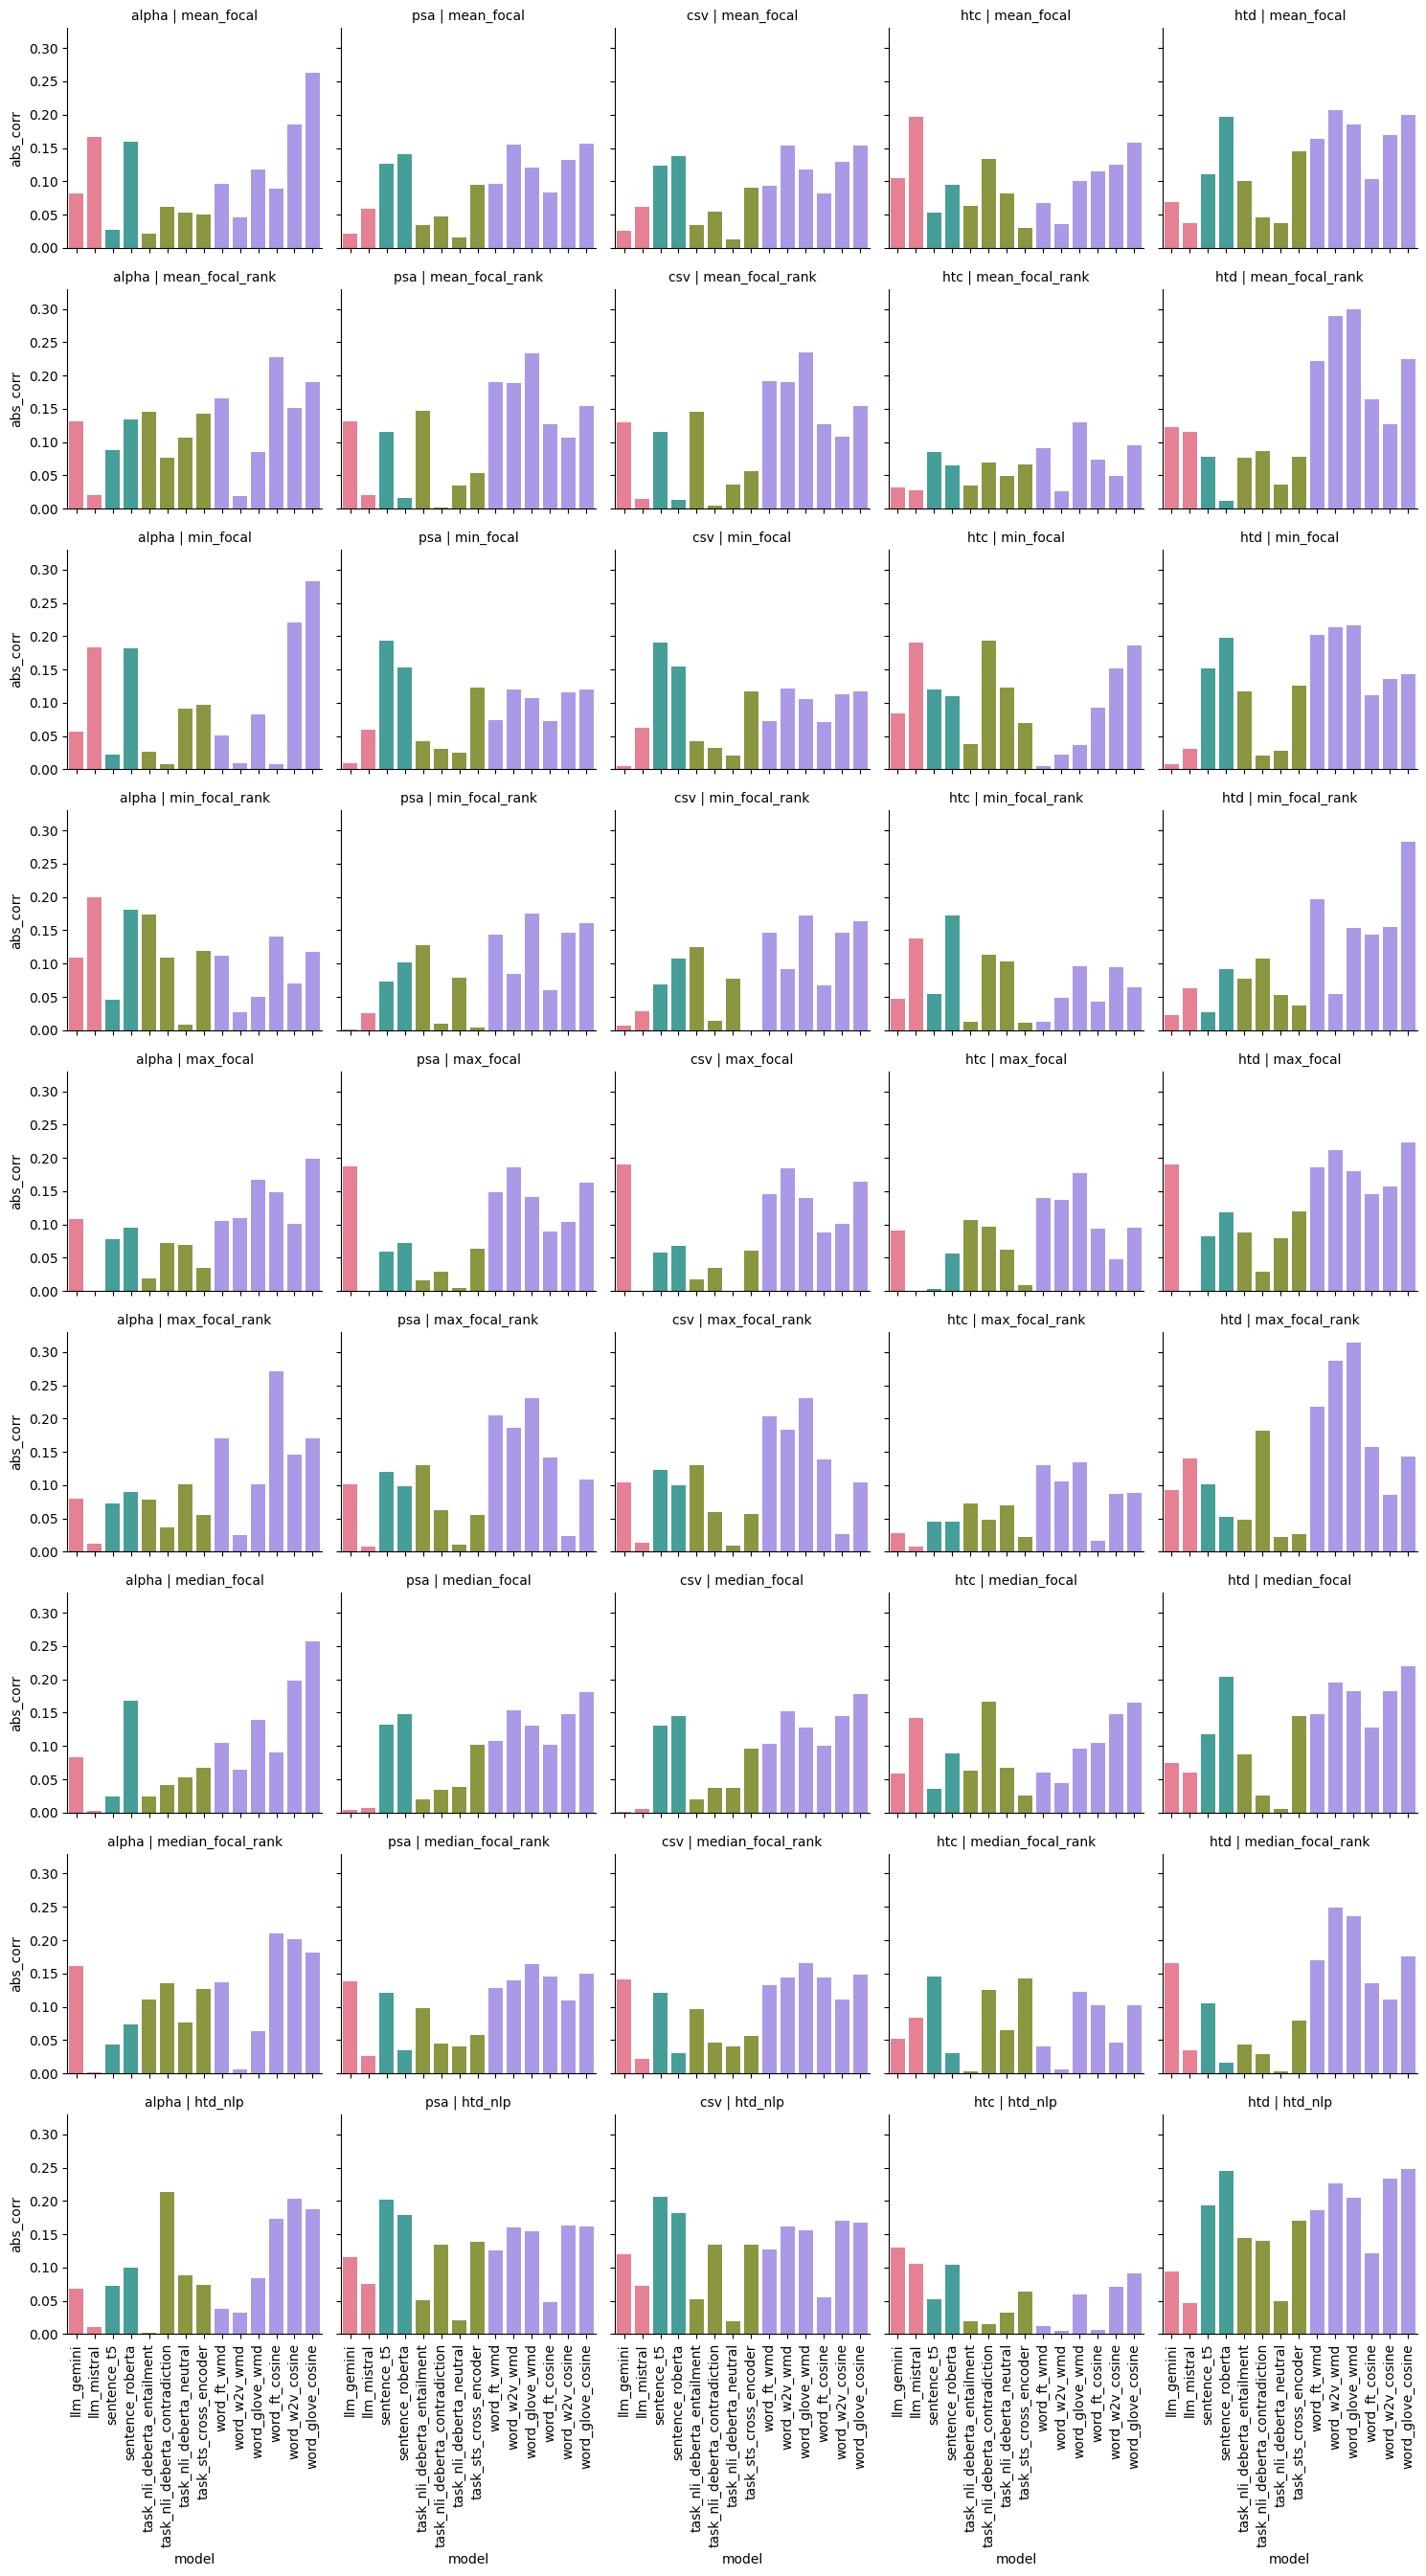

In [60]:
plot_facetgrid('colqitt_et_al')

C:\Users\hide\AppData\Local\Temp\ipykernel_7328\2817206245.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  g.figure.show()


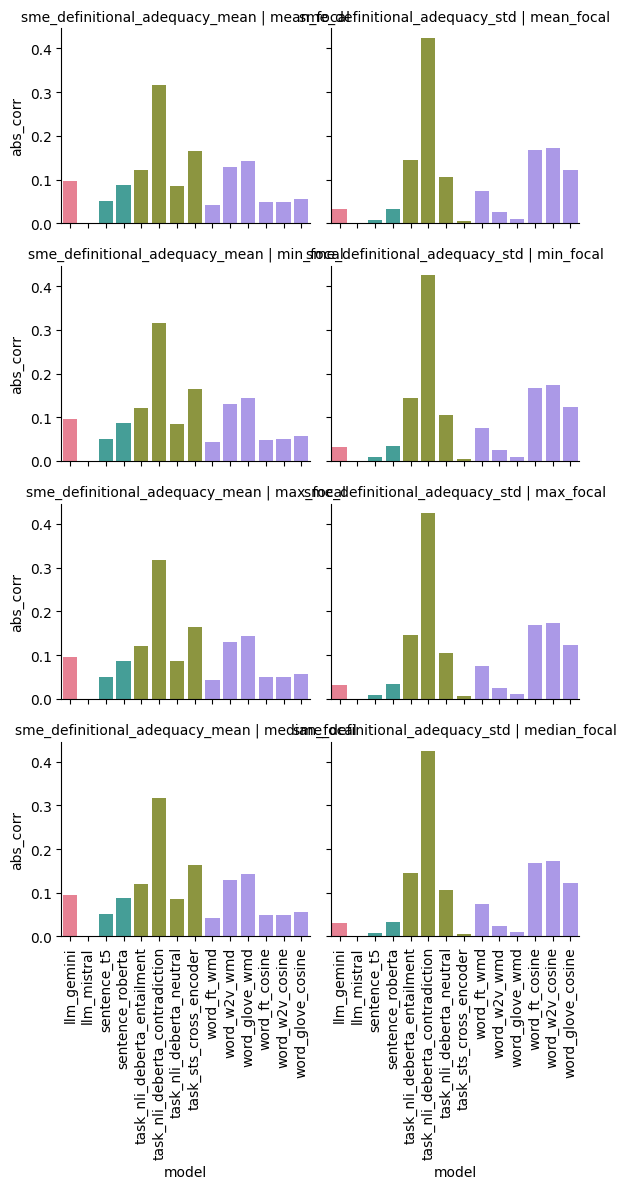

In [61]:
plot_facetgrid('matthews_et_al')